# LoomAnalysisCR - multi-experiment loom analysis

This notebook extends the legacy `CLfull...` loom analyses to the dynamically selected 2026 shoaling-selection experiments. Each recording is reduced to pooled or genotype-specific experiment-level values before experiments are combined, so experiments remain equally weighted replicates.

## Settings

In [1]:
# Import tools for working with folders/paths and environment variables.
from pathlib import Path
import os

# Start from the folder in which Jupyter is currently running.
# If the notebook was opened from the Analyses folder, move one level up so
# imports such as `functions...` are resolved from the repository root.
repo_candidate = Path.cwd()
if repo_candidate.name == 'Analyses':
    repo_candidate = repo_candidate.parent
# An environment variable can override the automatically detected code folder.
# `.resolve()` converts the result to a complete (absolute) path.
CODE_DIR = Path(os.environ.get('JLSOCIALBEHAVIOR_CODE_DIR', repo_candidate)).resolve()
os.chdir(CODE_DIR)

# Input/output locations. `Path` objects make joining folders and filenames
# safer and clearer than manually concatenating strings.
#META_FOLDER = Path('//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/07_Data/Carlos/Behavior/ShoalingSelection/')
META_FOLDER = Path('//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/07_Data/Carlos/Behavior/QTL/')
#META_FILE = 'MetaData_CR.xlsx'
META_FILE = "MetaData_QTL.xlsx"  # Use this line to switch to the QTL metadata file.
#PROCESSING_ROOT_DIR = Path('//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_Use/temp/shoaling_selection/')
PROCESSING_ROOT_DIR = Path('//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_Use/temp/shoaling_selection/ShoalQTL_temp_processing/')
# The `/` operator joins Path objects; it does not mean division here.
PROCESSING_DIR = PROCESSING_ROOT_DIR / 'LoomAnalysisCR_temp_processing'

# Experiment-selection settings. A value of `None` means "do not filter on
# this property"; a list means "include/exclude these specific values".
# Cohort date controls. Dates use ISO format (YYYY-MM-DD).
DATE_FILTER_MODE = 'exclude_date_range'  # 'include_from_date' or 'exclude_date_range'
INCLUDE_FROM_DATE = '2026-01-01'
EXCLUDE_DATE_START = '2025-08-01'
EXCLUDE_DATE_END = '2026-01-01'
INCLUDE_LINES = None
INCLUDE_GENOTYPES = None
INCLUDE_LINESETS = None
INCLUDE_EXPERIMENT_FOLDERS = None
EXCLUDE_EXPERIMENT_FOLDERS = ['20250128_01_35Animals_dn_TLSel1F9']

# Plot settings shared by later cells. When splitting is enabled, each
# requested genotype is drawn separately instead of combining all fish.
# Global display controls. Genotype matching ignores case and surrounding whitespace.
SPLIT_PLOTS_BY_GENOTYPE = True
INCLUDED_PLOT_GENOTYPES = ['hi', 'lo', 'F2']

# Analysis-window settings, measured in video frames unless noted otherwise.
# These values are passed to the helper that extracts behavior from raw data.
# Raw extraction and cache controls inherited from the original loom notebook.
# False reuses previously processed tables when possible; True rebuilds them.
FORCE_REPROCESS_RAW_DATA = False
LEGACY_ONSET_IN_BLOCK = 150
PRE_FRAMES = 50
POST_FRAMES = 99
# Frame intervals used to define pre-stimulus baseline and response periods.
BASELINE_FRAMES = (100, 140)
RESPONSE_FRAMES = (149, 180)
VELOCITY_FRAME_START = 0
VELOCITY_FRAME_END = 300
VELOCITY_STEP_FRAMES = 30
# Conversion constants: frames per second and tracking units per millimetre.
FPS = 30
UNITS_PER_MM = 4.0
MAX_VELOCITY_WINDOW_FRAMES = 120

# Print the resolved paths as a quick check before time-consuming processing.
print('Using repository:', CODE_DIR)
print('Using metadata:', META_FOLDER / META_FILE)
print('Using loom cache:', PROCESSING_DIR)

Using repository: C:\Users\crodri19\larschpostdoc_analyses\selection_shoaling\jlsocialbehavior
Using metadata: \\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsch\default\D2c\07_Data\Carlos\Behavior\QTL\MetaData_QTL.xlsx
Using loom cache: \\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsch\default\D2c\03_Common_Use\temp\shoaling_selection\ShoalQTL_temp_processing\LoomAnalysisCR_temp_processing


## Imports and plotting utilities

In [2]:
# Import the main libraries used throughout the notebook:
# - matplotlib creates plots
# - NumPy performs numerical/array operations
# - pandas stores and manipulates tables (DataFrames)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# Jupyter "magic" commands begin with `%`. They configure the notebook:
# avoid automatic pylab imports, show plots below cells, and reload edited
# helper modules automatically before rerunning code.
%config InteractiveShellApp.pylab_import_all = False
%matplotlib inline
%reload_ext autoreload
%autoreload 2

# Import project-specific analysis functions under the short name `loom`.
import functions.joh_loom_helpers as loom

# Set consistent plot styling and make wide pandas tables easier to inspect.
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 180)

# Allowed ways of representing points in summary plots, plus reusable visual
# encodings (side colours and marker shapes).
POINT_MODES = {'experiments', 'condition_trial_average'}
SIDE_COLORS = {'L': '#7b4ab8', 'R': '#cf5a33'}
GENOTYPE_MARKERS = ['o', 's', '^', 'D', 'P', 'X', 'v', '<', '>']

# Fail early when a plotting-mode setting contains a typo or unsupported value.
def validate_point_mode(mode):
    if mode not in POINT_MODES:
        raise ValueError(f'Point mode must be one of {sorted(POINT_MODES)}; got {mode!r}.')

# Return evenly spaced horizontal offsets. Jitter prevents points with the
# same x-coordinate from hiding one another; unlike random jitter, this gives
# the same plot every time the cell is run.
def deterministic_jitter(n, width=0.10):
    return np.linspace(-width, width, n) if n > 1 else np.zeros(n)

# Translate a normalized genotype key into the label shown to readers.
def genotype_display(genotype):
    return GENOTYPE_DISPLAY.get(genotype, str(genotype))

# Keep only the genotype groups that should appear in plots. `.copy()` makes
# an independent DataFrame, avoiding accidental edits to the original table.
def select_plot_rows(frame):
    groups = ACTIVE_GENOTYPES if SPLIT_PLOTS_BY_GENOTYPE else [loom.POOLED_GENOTYPE]
    return frame.loc[frame['genotype'].isin(groups)].copy()

# Add genotype to a list of grouping columns. The starred expression `*columns`
# unpacks the supplied list into the new list.
def plot_group_columns(columns):
    return [*columns, 'genotype']

## Select experiments

Selection uses `AllExp` and `AllAn` from the shared metadata workbook. The year and optional line/genotype/lineSet/folder filters have the same intersection semantics as the neighborhood-map notebook.

In [3]:
# Read the metadata spreadsheet and apply all filters configured above.
# The function returns two DataFrames: usable experiments and selected rows
# whose required raw PositionTxt file could not be found.
experiments, missing_inputs = loom.select_loom_experiments(
    META_FOLDER / META_FILE,
    date_filter_mode=DATE_FILTER_MODE,
    include_from_date=INCLUDE_FROM_DATE,
    exclude_date_start=EXCLUDE_DATE_START,
    exclude_date_end=EXCLUDE_DATE_END,
    include_lines=INCLUDE_LINES,
    include_genotypes=INCLUDE_GENOTYPES,
    include_line_sets=INCLUDE_LINESETS,
    include_folders=INCLUDE_EXPERIMENT_FOLDERS,
    exclude_folders=EXCLUDE_EXPERIMENT_FOLDERS,
)

# Check that selection succeeded and report missing inputs without silently
# treating them as analyzed experiments.
print(f'Included experiments after date and metadata filtering: {len(experiments)}')
if experiments.empty:
    raise ValueError('No usable experiments passed the current metadata and raw-file filters.')
if not missing_inputs.empty:
    print(f'WARNING: {len(missing_inputs)} selected metadata rows have no PositionTxt input:')
    display(missing_inputs)

# Build genotype summaries at three levels: all values accepted by metadata,
# values actually present after filtering, and requested values available to plot.
VALID_GENOTYPES = loom.loom_genotype_catalog(META_FOLDER / META_FILE)
# This set comprehension visits every experiment's animal-to-genotype mapping.
# A set removes duplicates; `sorted` gives a stable readable order.
PRESENT_GENOTYPES = sorted({
    genotype
    for mapping in experiments['animal_genotypes']
    for genotype in mapping.values()
})
# Normalize requested genotype names and separate available from absent ones.
ACTIVE_GENOTYPES, missing_requested_genotypes = loom.resolve_requested_genotypes(
    INCLUDED_PLOT_GENOTYPES, PRESENT_GENOTYPES
)
# Dictionaries map normalized genotype keys to display labels, colours, and
# marker shapes. `%` cycles through marker shapes if there are many genotypes.
GENOTYPE_DISPLAY = {loom.normalize_genotype(value): str(value).strip() for value in INCLUDED_PLOT_GENOTYPES}
GENOTYPE_DISPLAY[loom.POOLED_GENOTYPE] = 'pooled'
GENOTYPE_COLORS = {
    'hi': "#d67c27",   # red
    'lo': '#1f77b4',   # blue
    'f2': '#2ca02c',   # green
}
GENOTYPE_MARKER_MAP = {genotype: GENOTYPE_MARKERS[index % len(GENOTYPE_MARKERS)] for index, genotype in enumerate(ACTIVE_GENOTYPES)}

print('All valid metadata genotypes:', VALID_GENOTYPES)
print('Genotypes present in selected cohort:', PRESENT_GENOTYPES)
# Convert all fish genotypes to a Series, count each category, and turn the
# result back into a tidy DataFrame for display.
selected_genotype_counts = (
    pd.Series([genotype for mapping in experiments['animal_genotypes'] for genotype in mapping.values()], name='genotype')
    .value_counts()
    .rename_axis('genotype')
    .rename('n_selected_fish')
    .reset_index()
)
display(selected_genotype_counts)
# Warn about recoverable omissions, but stop if genotype-split plotting was
# requested and none of the requested genotypes is available.
if missing_requested_genotypes:
    print('Requested genotypes absent from selected cohort and skipped:', missing_requested_genotypes)
if SPLIT_PLOTS_BY_GENOTYPE and not ACTIVE_GENOTYPES:
    raise ValueError('None of INCLUDED_PLOT_GENOTYPES are present in the selected cohort.')

# Show the most useful metadata columns for a final selection sanity check.
display(experiments[[
    'experiment_index', 'experiment', 'exp_year', 'n_animals',
    'lines', 'genotypes', 'line_sets', 'txt_path'
]])

Included experiments after date and metadata filtering: 11
All valid metadata genotypes: ['esc', 'f2']
Genotypes present in selected cohort: ['esc', 'f2']


,genotype,n_selected_fish
0,f2,295
1,esc,67


Requested genotypes absent from selected cohort and skipped: ['hi', 'lo']


,experiment_index,experiment,exp_year,n_animals,lines,genotypes,line_sets,txt_path
0,0,20260511_q1_Sel1A_s1,2026,35,[Sel1A],"[esc, f2]",[Sel1A_11-05-2026],\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...
1,1,20260511_q2_Sel1A_s2,2026,35,[Sel1A],"[esc, f2]",[Sel1A_11-05-2026],\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...
2,2,20260512_q3_Sel3C_s1,2026,35,[Sel3C],"[esc, f2]",[Sel3C_12-05-2026],\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...
3,3,20260512_q4_Sel3C_s2,2026,35,[Sel3C],"[esc, f2]",[Sel3C_12-05-2026],\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...
4,4,20260518_q5_Sel3D_s1,2026,35,[Sel3D],"[esc, f2]",[Sel3D_18-05-2026],\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...
5,5,20260518_q6_Sel3D_s2,2026,35,[Sel3D],"[esc, f2]",[Sel3D_18-05-2026],\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...
6,6,20260519_q7_Sel1B_s1,2026,35,[Sel1B],"[esc, f2]",[Sel1B_19-05-2026],\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...
7,7,20260519_q8_Sel1B_s2,2026,35,[Sel1B],"[esc, f2]",[Sel1B_19-05-2026],\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...
8,8,20260626_q9_Sel1A_s2,2026,35,[Sel1A],[f2],[Sel1A_26-06-2026],\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...
9,9,20260731_q10_Sel3A_s1,2026,35,[Sel3A],[f2],[Sel3A_31-07-2026],\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...


## Extract or load compact loom tables

Raw recordings are processed one at a time. Cached experiment-level tables are reused only when their settings sidecar and raw-file signature still match.

In [5]:
# Load cached analysis tables when available, or extract them from raw tracking
# files. Every processing setting is passed by name so its meaning is explicit.
loom_tables = loom.collect_or_load_loom_analysis_data(
    experiments,
    PROCESSING_DIR,
    force_reprocess=FORCE_REPROCESS_RAW_DATA,
    onset_in_block=LEGACY_ONSET_IN_BLOCK,
    pre_frames=PRE_FRAMES,
    post_frames=POST_FRAMES,
    baseline_frames=BASELINE_FRAMES,
    response_frames=RESPONSE_FRAMES,
    velocity_frame_start=VELOCITY_FRAME_START,
    velocity_frame_end=VELOCITY_FRAME_END,
    velocity_step_frames=VELOCITY_STEP_FRAMES,
    fps=FPS,
    units_per_mm=UNITS_PER_MM,
    max_velocity_window_frames=MAX_VELOCITY_WINDOW_FRAMES,
)

# Give the five returned DataFrames short descriptive names:
# center_traces: distance from arena center at each frame
# response_metrics: baseline/response summaries
# trial_velocity: frame-by-frame velocity
# trial_max_velocity: one maximum-velocity summary per trial
# fish_trial_max_velocity: one maximum-velocity value per fish and trial
center_traces = loom_tables['center_traces']
response_metrics = loom_tables['response_metrics']
trial_velocity = loom_tables['trial_velocity']
trial_max_velocity = loom_tables['trial_max_velocity']
fish_trial_max_velocity = loom_tables['fish_trial_max_velocity']

# Build a compact quality-control table. The list comprehensions count rows
# and unique experiments for every returned table.
display(pd.DataFrame({
    'table': list(loom_tables),
    'rows': [len(loom_tables[name]) for name in loom_tables],
    'experiments': [loom_tables[name]['experiment'].nunique() for name in loom_tables],
}))

Processing loom experiment 1/11: 20260511_q1_Sel1A_s1 (missing or stale cache)
Processing loom experiment 2/11: 20260511_q2_Sel1A_s2 (missing or stale cache)


C:\Users\crodri19\AppData\Local\Temp\ipykernel_2924\2717735648.py:3: UserWarning: Skipping loom experiment 20260511_q1_Sel1A_s1: no CLfull loom stimulus episodes were found.
  loom_tables = loom.collect_or_load_loom_analysis_data(


Processing loom experiment 3/11: 20260512_q3_Sel3C_s1 (missing or stale cache)
Processing loom experiment 4/11: 20260512_q4_Sel3C_s2 (missing or stale cache)
Processing loom experiment 5/11: 20260518_q5_Sel3D_s1 (missing or stale cache)
Processing loom experiment 6/11: 20260518_q6_Sel3D_s2 (missing or stale cache)
Processing loom experiment 7/11: 20260519_q7_Sel1B_s1 (missing or stale cache)
Processing loom experiment 8/11: 20260519_q8_Sel1B_s2 (missing or stale cache)
Processing loom experiment 9/11: 20260626_q9_Sel1A_s2 (missing or stale cache)
Processing loom experiment 10/11: 20260731_q10_Sel3A_s1 (missing or stale cache)
Processing loom experiment 11/11: 20260731_q11_Sel3A_s2 (missing or stale cache)


C:\Users\crodri19\AppData\Local\Temp\ipykernel_2924\2717735648.py:3: UserWarning: Skipping loom experiment 20260731_q10_Sel3A_s1: no CLfull loom stimulus episodes were found.
  loom_tables = loom.collect_or_load_loom_analysis_data(
C:\Users\crodri19\AppData\Local\Temp\ipykernel_2924\2717735648.py:3: UserWarning: Skipping loom experiment 20260731_q11_Sel3A_s2: no CLfull loom stimulus episodes were found.
  loom_tables = loom.collect_or_load_loom_analysis_data(


,table,rows,experiments
0,center_traces,55200,8
1,response_metrics,552,8
2,trial_velocity,9760,8
3,trial_max_velocity,976,8


## 1. Legacy center-distance traces

Repeated trials and animals were averaged within each experiment and selected plot group during extraction. Lines and SEM bands below therefore summarize equally weighted experiment traces.

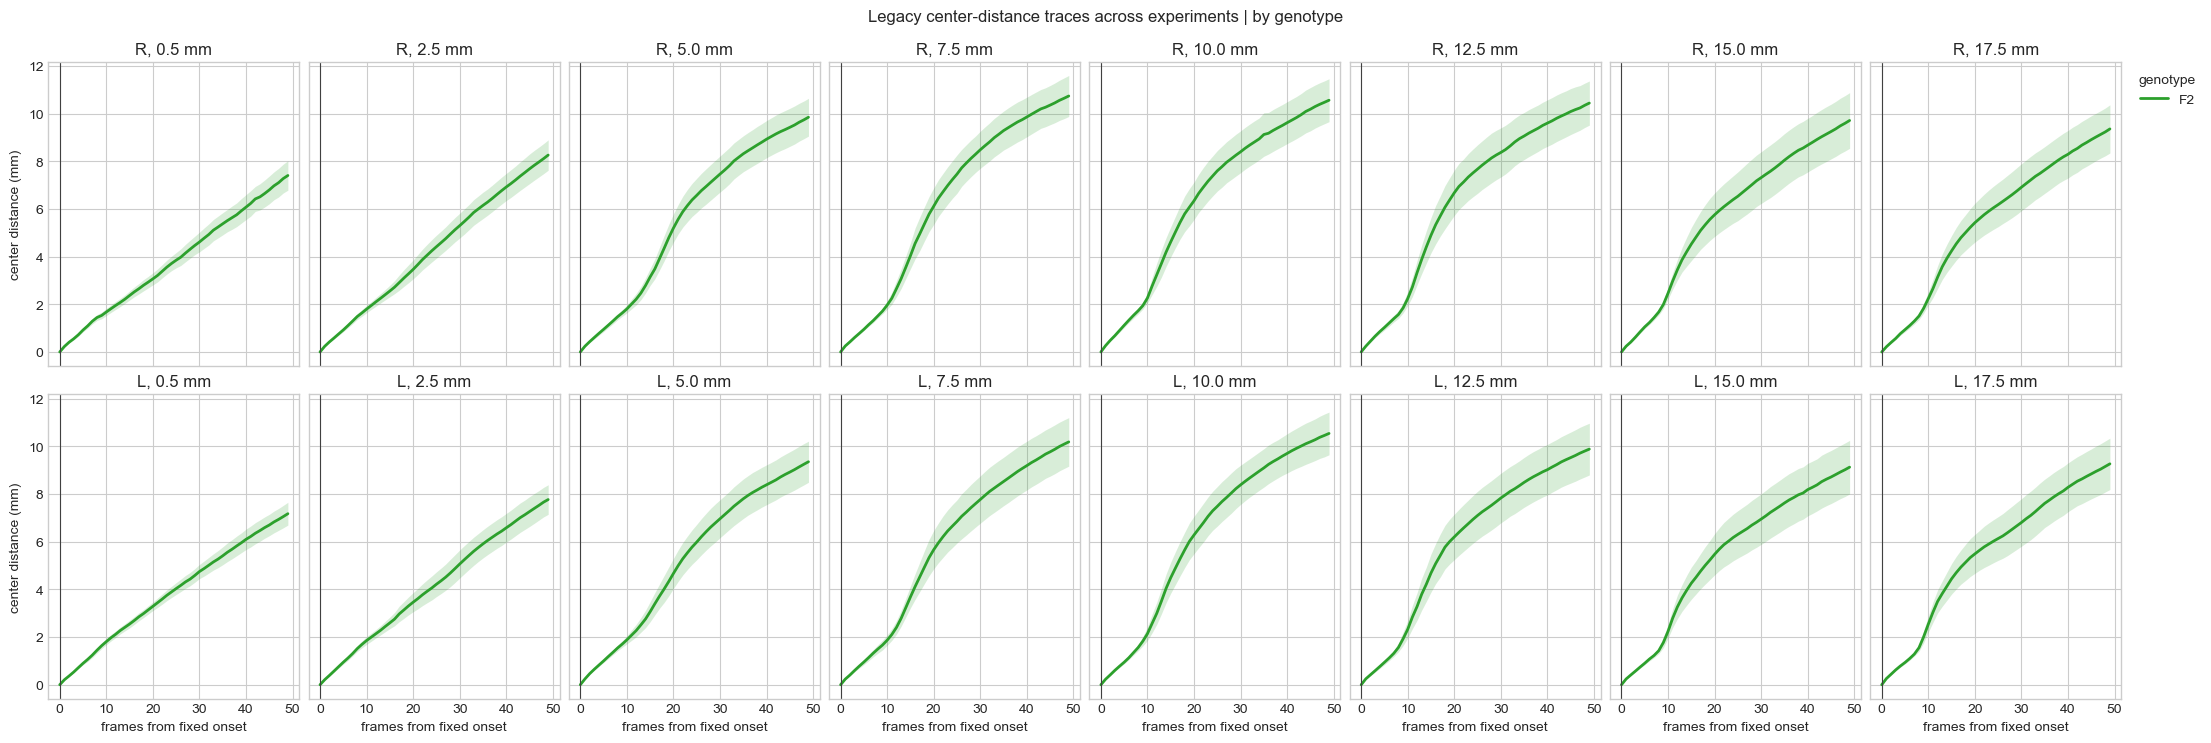

,loom_max_size,side,relative_frame,genotype,center_dist_mm_mean,center_dist_mm_sem,n_experiments
0,1,L,0,f2,0.000000,0.000000,8
1,1,L,1,f2,0.209325,0.005003,8
2,1,L,2,f2,0.367266,0.015882,8
3,1,L,3,f2,0.533252,0.025855,8
4,1,L,4,f2,0.717397,0.043820,8


In [6]:
# Restrict traces to frames 0 through 49 relative to the fixed loom onset.
CENTER_TRACE_FRAME_RANGE = (0, 49)

# `.between(*range)` expands the tuple into lower and upper limits. `.loc[...]`
# selects matching rows, and `.copy()` makes the selection independent.
center_window = center_traces.loc[
    center_traces['relative_frame'].between(*CENTER_TRACE_FRAME_RANGE)
].copy()
center_window = select_plot_rows(center_window)
# For every loom size, side, frame, and genotype, calculate the across-experiment
# mean, standard error of the mean (SEM), and experiment count.
center_stats = loom.summarize_across_experiments(
    center_window,
    plot_group_columns(['loom_max_size', 'side', 'relative_frame']),
    ['center_dist_mm'],
)
# Create a grid with one row per loom side and one column per loom size.
# Sharing axes makes panels directly comparable; constrained_layout reduces overlap.
all_sizes = sorted(center_stats['loom_max_size'].unique())
fig, axes = plt.subplots(2, len(all_sizes), figsize=(22, 7), sharex=True, sharey=True, constrained_layout=True)
# With one size matplotlib returns a 1-D axes array; reshape it so later
# two-index access (`axes[row, column]`) works in all cases.
if len(all_sizes) == 1:
    axes = np.asarray(axes).reshape(2, 1)

# Nested loops visit every panel. `enumerate` supplies both the array index
# and the corresponding side/size value.
for row_index, side in enumerate(['R', 'L']):
    for column_index, size in enumerate(all_sizes):
        ax = axes[row_index, column_index]
        plot_genotypes = ACTIVE_GENOTYPES if SPLIT_PLOTS_BY_GENOTYPE else [loom.POOLED_GENOTYPE]
        # Within each panel, draw one trace per genotype (or one pooled trace).
        for genotype in plot_genotypes:
            # Boolean conditions joined with `&` select the current side, size, and genotype.
            # Sorting by frame ensures points are connected in chronological order.
            trace = center_stats.loc[
                center_stats['side'].eq(side)
                & center_stats['loom_max_size'].eq(size)
                & center_stats['genotype'].eq(genotype)
            ].sort_values('relative_frame')
            # Some combinations may have no observations; skip them safely.
            if trace.empty:
                continue
            # Convert pandas columns to floating-point NumPy arrays for plotting.
            # `mean` is the line and `sem` determines the shaded uncertainty band.
            x = trace['relative_frame'].to_numpy(dtype=float)
            mean = trace['center_dist_mm_mean'].to_numpy(dtype=float)
            sem = trace['center_dist_mm_sem'].to_numpy(dtype=float)
            color = GENOTYPE_COLORS[genotype] if SPLIT_PLOTS_BY_GENOTYPE else SIDE_COLORS[side]
            label = genotype_display(genotype) if SPLIT_PLOTS_BY_GENOTYPE else side
            # The solid line is the mean across experiments. The shaded band is
            # mean ± SEM (standard error of the mean across experiments), not SD.
            ax.plot(x, mean, color=color, lw=2, label=label)
            ax.fill_between(x, mean - sem, mean + sem, color=color, alpha=0.18, lw=0)
        # Mark stimulus onset at frame zero, then label each panel and outer axes.
        ax.axvline(0, color='0.25', lw=0.8)
        ax.set_title(f'{side}, {size / 2:.1f} mm')
        if column_index == 0:
            ax.set_ylabel('center distance (mm)')
        if row_index == 1:
            ax.set_xlabel('frames from fixed onset')
# Add a single legend only when multiple genotype traces need identification.
if SPLIT_PLOTS_BY_GENOTYPE:
    axes[0, -1].legend(title='genotype', bbox_to_anchor=(1.02, 1), loc='upper left')
mode_label = 'by genotype' if SPLIT_PLOTS_BY_GENOTYPE else 'pooled fish'
fig.suptitle(f'Legacy center-distance traces across experiments | {mode_label}', y=1.04)
# Render the completed figure, then show the first summary rows for inspection.
plt.show()
display(center_stats.head())

## 2. Legacy baseline/response metrics

The source hierarchy is preserved within each experiment and genotype: repeated trials are averaged per animal, then animals are averaged. `BASELINE_POINT_MODE` shows experiment replicates or cross-experiment condition averages; the global genotype switch selects pooled or genotype-specific cache rows.

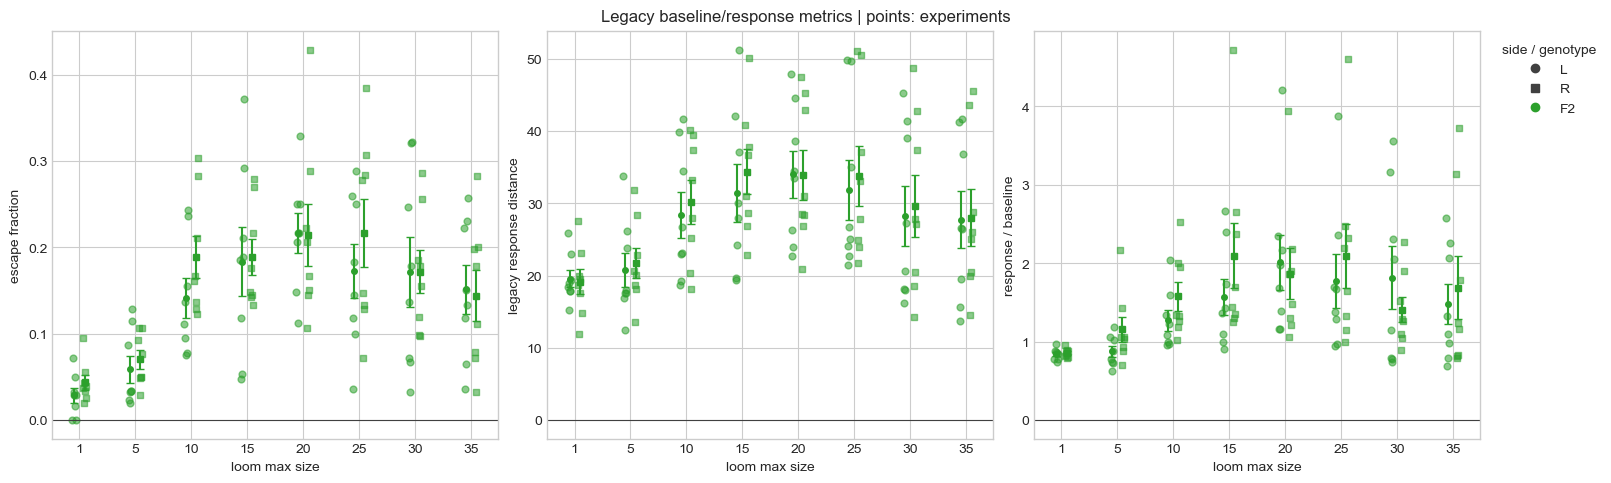

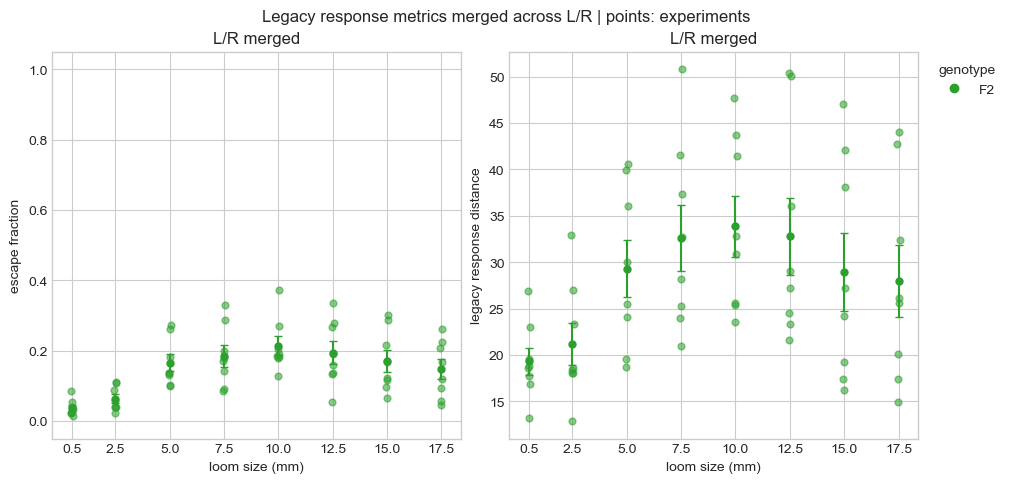

,loom_max_size,side,genotype,escape_mean,response_dist_mean,response_over_baseline_mean,n_animals_mean,escape_sem,response_dist_sem,response_over_baseline_sem,n_animals_sem,n_experiments
0,1,L,f2,0.028542,19.562463,0.838671,26.25,0.008540,1.186335,0.025682,2.547758,8
1,1,R,f2,0.043678,19.144837,0.856090,26.25,0.008312,1.689947,0.020514,2.547758,8
2,5,L,f2,0.058907,20.780052,0.875972,26.25,0.015481,2.388941,0.068671,2.547758,8
3,5,R,f2,0.070200,21.763396,1.155142,26.25,0.010549,2.063792,0.162091,2.547758,8
4,10,L,f2,0.141439,28.337207,1.275178,26.25,0.023538,3.210780,0.134173,2.547758,8
5,10,R,f2,0.188961,30.220960,1.577858,26.25,0.024696,3.032623,0.183763,2.547758,8
6,15,L,f2,0.183430,31.430642,1.573652,26.25,0.039535,3.979537,0.229846,2.547758,8
7,15,R,f2,0.188805,34.363413,2.096096,26.25,0.020788,3.102815,0.417357,2.547758,8
8,20,L,f2,0.216105,33.985512,2.014828,26.25,0.023269,3.303992,0.350729,2.547758,8
9,20,R,f2,0.214264,33.909976,1.868096,26.25,0.036403,3.491653,0.325668,2.547758,8


,loom_max_size,genotype,escape_mean,response_dist_mean,response_over_baseline_mean,n_animals_mean,escape_sem,response_dist_sem,response_over_baseline_sem,n_animals_sem,n_experiments
0,1,f2,0.037560,19.337379,0.849327,26.25,0.008038,1.449633,0.019503,2.547758,8
1,5,f2,0.063335,21.161351,0.986073,26.25,0.012089,2.238371,0.089517,2.547758,8
2,10,f2,0.165666,29.299218,1.425904,26.25,0.024100,3.087201,0.144061,2.547758,8
3,15,f2,0.185508,32.607959,1.786146,26.25,0.030647,3.574996,0.218619,2.547758,8
4,20,f2,0.214291,33.887512,1.941301,26.25,0.026269,3.273267,0.257679,2.547758,8
5,25,f2,0.194581,32.793714,1.930899,26.25,0.033019,4.117677,0.365265,2.547758,8
6,30,f2,0.171549,28.923969,1.612150,26.25,0.031396,4.221678,0.268060,2.547758,8
7,35,f2,0.147179,27.929851,1.605373,26.25,0.028433,3.881004,0.331030,2.547758,8


In [7]:
# Choose whether visible points represent individual experiments or already
# averaged condition/trial values; validate the choice immediately.
BASELINE_POINT_MODE = 'experiments'  # 'experiments' or 'condition_trial_average'
validate_point_mode(BASELINE_POINT_MODE)
plot_genotypes = ACTIVE_GENOTYPES if SPLIT_PLOTS_BY_GENOTYPE else [loom.POOLED_GENOTYPE]

# Keep side-resolved response rows and the requested genotype groups.
side_response = select_plot_rows(response_metrics.loc[response_metrics['aggregation'].eq('side_resolved')])
# Summarize response variables across experiments for every size/side/genotype.
side_stats = loom.summarize_across_experiments(
    side_response, plot_group_columns(['loom_max_size', 'side']),
    ['escape', 'response_dist', 'response_over_baseline', 'n_animals'],
)
# Set base x positions and small offsets so side/genotype combinations do not overlap.
sizes = sorted(side_response['loom_max_size'].unique())
x_base = np.arange(len(sizes), dtype=float)
combination_count = 2 * len(plot_genotypes)
offset_step = 0.36 if not SPLIT_PLOTS_BY_GENOTYPE else min(0.18, 0.72 / max(1, combination_count))
# Create one panel for each response metric listed in the loop below.
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True)

# Each tuple links a subplot, DataFrame column, and human-readable y-axis label.
for ax, metric, ylabel in [
    (axes[0], 'escape', 'escape fraction'),
    (axes[1], 'response_dist', 'legacy response distance'),
    (axes[2], 'response_over_baseline', 'response / baseline'),
]:
    for side_index, side in enumerate(['L', 'R']):
        for genotype_index, genotype in enumerate(plot_genotypes):
            # Flatten the side/genotype pair to one index and center its horizontal offset.
            combination_index = side_index * len(plot_genotypes) + genotype_index
            offset = (combination_index - (combination_count - 1) / 2) * offset_step
            color = GENOTYPE_COLORS[genotype] if SPLIT_PLOTS_BY_GENOTYPE else SIDE_COLORS[side]
            marker = 'o' if side == 'L' else 's'
            for size_index, size in enumerate(sizes):
                position = x_base[size_index] + offset
                # Select raw rows and the corresponding one-row summary for this combination.
                mask = side_response['side'].eq(side) & side_response['loom_max_size'].eq(size) & side_response['genotype'].eq(genotype)
                raw = side_response.loc[mask]
                stats = side_stats.loc[side_stats['side'].eq(side) & side_stats['loom_max_size'].eq(size) & side_stats['genotype'].eq(genotype)]
                if stats.empty:
                    continue
                stats = stats.iloc[0]
                # In experiment mode show every experiment with slight horizontal jitter.
                # Otherwise show one condition/trial mean. The error bar always shows mean ± SEM.
                if BASELINE_POINT_MODE == 'experiments':
                    values = raw[metric].dropna().to_numpy(dtype=float)
                    ax.scatter(position + deterministic_jitter(len(values), 0.035), values, color=color, marker=marker, alpha=0.55, s=24)
                else:
                    ax.scatter(position, stats[f'{metric}_mean'], color=color, marker=marker, s=42, zorder=3)
                # The marker is the across-experiment mean; each vertical error bar
                # extends one SEM above and below it. It is not a standard deviation.
                ax.errorbar(position, stats[f'{metric}_mean'], yerr=stats[f'{metric}_sem'], color=color, marker=marker, capsize=3, ms=4, zorder=4)
    # Add a zero reference line and finish tick and axis labels for this panel.
    ax.axhline(0, color='0.25', lw=0.8)
    ax.set_xticks(x_base)
    ax.set_xticklabels([str(size) for size in sizes])
    ax.set_xlabel('loom max size')
    ax.set_ylabel(ylabel)
# Build custom legend symbols: marker shape represents side and colour represents genotype.
legend_handles = [plt.Line2D([], [], marker=('o' if side == 'L' else 's'), color='0.25', linestyle='None', label=side) for side in ['L', 'R']]
if SPLIT_PLOTS_BY_GENOTYPE:
    legend_handles += [plt.Line2D([], [], marker='o', color=GENOTYPE_COLORS[g], linestyle='None', label=genotype_display(g)) for g in plot_genotypes]
axes[-1].legend(handles=legend_handles, title='side / genotype', bbox_to_anchor=(1.02, 1), loc='upper left')
fig.suptitle(f'Legacy baseline/response metrics | points: {BASELINE_POINT_MODE}', y=1.04)
plt.show()

# Repeat the analysis after combining left- and right-side trials (`lr_merged`).
merged_response = select_plot_rows(response_metrics.loc[response_metrics['aggregation'].eq('lr_merged')])
merged_stats = loom.summarize_across_experiments(
    merged_response, plot_group_columns(['loom_max_size']),
    ['escape', 'response_dist', 'response_over_baseline', 'n_animals'],
)
# Convert maximum loom diameter to the plotted loom size using division by two,
# then offset genotypes slightly around each size.
size_x = np.asarray(sizes, dtype=float) / 2.0
genotype_offsets = np.linspace(-0.22, 0.22, len(plot_genotypes)) if len(plot_genotypes) > 1 else np.zeros(1)
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), constrained_layout=True)
# Draw raw/averaged points and mean ± SEM using the same logic as above.
for ax, metric, ylabel in [(axes[0], 'escape', 'escape fraction'), (axes[1], 'response_dist', 'legacy response distance')]:
    for genotype_index, genotype in enumerate(plot_genotypes):
        color = GENOTYPE_COLORS[genotype] if SPLIT_PLOTS_BY_GENOTYPE else '#3569b8'
        for size_index, size in enumerate(sizes):
            position = size_x[size_index] + genotype_offsets[genotype_index]
            mask = merged_response['loom_max_size'].eq(size) & merged_response['genotype'].eq(genotype)
            raw = merged_response.loc[mask]
            stats = merged_stats.loc[merged_stats['loom_max_size'].eq(size) & merged_stats['genotype'].eq(genotype)]
            if stats.empty:
                continue
            stats = stats.iloc[0]
            if BASELINE_POINT_MODE == 'experiments':
                values = raw[metric].dropna().to_numpy(dtype=float)
                ax.scatter(position + deterministic_jitter(len(values), 0.05), values, color=color, alpha=0.55, s=24)
            else:
                ax.scatter(position, stats[f'{metric}_mean'], color=color, s=42, zorder=3)
            # The vertical error bar is mean ± one SEM across experiments, not SD.
            ax.errorbar(position, stats[f'{metric}_mean'], yerr=stats[f'{metric}_sem'], color=color, marker='o', capsize=3, ms=5, zorder=4)
    ax.set_xlabel('loom size (mm)')
    ax.set_ylabel(ylabel)
    ax.set_xticks(size_x)
    ax.set_title('L/R merged')
# Escape is a fraction, so use a y-range just beyond the valid 0-to-1 interval.
axes[0].set_ylim(-0.05, 1.05)
if SPLIT_PLOTS_BY_GENOTYPE:
    axes[-1].legend(handles=[plt.Line2D([], [], marker='o', color=GENOTYPE_COLORS[g], linestyle='None', label=genotype_display(g)) for g in plot_genotypes], title='genotype', bbox_to_anchor=(1.02, 1), loc='upper left')
fig.suptitle(f'Legacy response metrics merged across L/R | points: {BASELINE_POINT_MODE}', y=1.04)
plt.show()
# Display complete sorted summary tables underlying both figures.
display(side_stats.sort_values(['genotype', 'loom_max_size', 'side']))
display(merged_stats.sort_values(['genotype', 'loom_max_size']))

## 3. Trial max post-loom velocity vs time since experiment start

Each native point is one experiment×genotype×trial value: the median across the selected fish of each fish's maximum speed during the post-loom window. Pooled mode uses the exact all-fish median. The alternative point mode averages matching size/side/condition trials across experiments. Each displayed genotype is fit independently with an estimated-floor Gaussian peak that captures the initial rise and subsequent decline. The fitted peak and rate summaries are descriptive and follow the selected point mode; loom size and time are partly confounded by the protocol sequence.

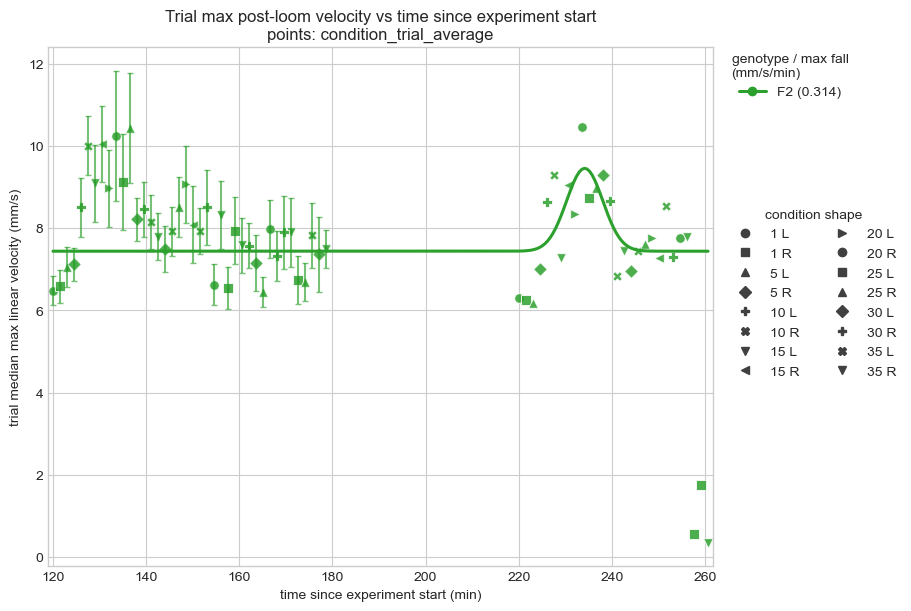

,genotype,fitted_floor_mm_s,amplitude_mm_s,peak_velocity_mm_s,peak_time_min,width_min,max_decrease_rate_mm_s_per_min,max_decrease_time_min,half_decay_time_min,r_squared,n_points,fit_status
0,f2,7.439014,2.015576,9.45459,234.125619,3.890518,0.314228,238.016137,4.580735,0.075002,68,ok


,loom_max_size,side,condition_trial,genotype,plot_x,plot_y,plot_x_sem,plot_y_sem,n_experiments,condition
0,1,L,1,f2,120.083333,6.477966,0.0,0.356446,8,1 L
1,1,L,2,f2,154.583333,6.626596,0.0,0.493073,8,1 L
2,1,L,3,f2,220.083333,6.294839,NaN,NaN,1,1 L
3,1,L,4,f2,254.583333,7.754031,NaN,NaN,1,1 L
4,1,R,1,f2,121.583333,6.590185,0.0,0.403131,8,1 R
5,1,R,2,f2,157.583333,6.542081,0.0,0.516198,8,1 R
6,1,R,3,f2,172.583333,6.748026,0.0,0.583554,8,1 R
7,1,R,4,f2,221.583333,6.250000,NaN,NaN,1,1 R
8,1,R,5,f2,257.583333,0.559017,NaN,NaN,1,1 R
9,5,L,1,f2,123.083333,7.056089,0.0,0.489530,8,5 L


In [9]:
# Configure point aggregation and discard small looms at or below the threshold.
TIME_POINT_MODE = 'condition_trial_average'  # 'experiments' or 'condition_trial_average'
MAX_LOOM_SIZE_EXCLUDE_THRESHOLD = 0
validate_point_mode(TIME_POINT_MODE)

# Select eligible trials and genotype groups; this is the source table for the plot.
time_source = trial_max_velocity.loc[
    trial_max_velocity['loom_max_size'].gt(MAX_LOOM_SIZE_EXCLUDE_THRESHOLD)
].copy()
time_source = select_plot_rows(time_source)
value_column = 'trial_median_max_linear_velocity_mm_s'
# Standardize both point modes to common plotting columns. In experiment mode
# each row is a point and SEM is undefined (NaN = "not a number").
if TIME_POINT_MODE == 'experiments':
    time_points = time_source.copy()
    time_points['plot_x'] = time_points['time_since_experiment_start_min']
    time_points['plot_y'] = time_points[value_column]
    time_points['plot_x_sem'] = np.nan
    time_points['plot_y_sem'] = np.nan
    time_points['n_experiments'] = 1
else:
    # In average mode, group corresponding condition trials across experiments,
    # then rename generated mean/SEM columns to generic plotting names.
    time_points = loom.summarize_across_experiments(
        time_source,
        plot_group_columns(['loom_max_size', 'side', 'condition_trial']),
        ['time_since_experiment_start_min', value_column],
    ).rename(columns={
        'time_since_experiment_start_min_mean': 'plot_x',
        'time_since_experiment_start_min_sem': 'plot_x_sem',
        f'{value_column}_mean': 'plot_y',
        f'{value_column}_sem': 'plot_y_sem',
    })
# Combine loom size and side into a readable condition label, and assign a
# distinct marker shape to every unique condition.
time_points['condition'] = time_points['loom_max_size'].astype(int).astype(str) + ' ' + time_points['side'].astype(str)
conditions = time_points[['loom_max_size', 'side', 'condition']].drop_duplicates().sort_values(['loom_max_size', 'side'])
condition_marker_symbols = ['o', 's', '^', 'D', 'P', 'X', 'v', '<', '>']
CONDITION_MARKERS = {
    condition: condition_marker_symbols[index % len(condition_marker_symbols)]
    for index, condition in enumerate(conditions['condition'])
}
# Import nonlinear least-squares fitting only where it is needed.
from scipy.optimize import curve_fit

# Gaussian peak model: a baseline (`floor`) plus a bell-shaped response.
# `amplitude` is height above baseline, `peak_elapsed_time` locates the peak,
# and `width` controls how quickly the curve rises and falls.
def gaussian_peak(elapsed_time, floor, amplitude, peak_elapsed_time, width):
    return floor + amplitude * np.exp(-0.5 * ((elapsed_time - peak_elapsed_time) / width) ** 2)

# First draw all observations. Colour identifies genotype and marker shape
# identifies loom condition; averages also receive horizontal and vertical SEM bars.
fig, ax = plt.subplots(figsize=(9, 6), constrained_layout=True)
plot_genotypes = ACTIVE_GENOTYPES if SPLIT_PLOTS_BY_GENOTYPE else [loom.POOLED_GENOTYPE]
for condition in conditions['condition']:
    for genotype in plot_genotypes:
        subset = time_points.loc[time_points['condition'].eq(condition) & time_points['genotype'].eq(genotype)]
        if subset.empty:
            continue
        point_color = GENOTYPE_COLORS[genotype] if SPLIT_PLOTS_BY_GENOTYPE else '0.25'
        ax.scatter(subset['plot_x'], subset['plot_y'], color=point_color, marker=CONDITION_MARKERS[condition], s=48, alpha=0.85, edgecolor='white', linewidth=0.7)
        # Averaged points have two uncertainty bars: horizontal = ± one SEM of
        # time across experiments; vertical = ± one SEM of velocity across experiments.
        # Raw experiment points have no error bars because each point is one experiment.
        if TIME_POINT_MODE == 'condition_trial_average':
            ax.errorbar(subset['plot_x'], subset['plot_y'], xerr=subset['plot_x_sem'], yerr=subset['plot_y_sem'], fmt='none', ecolor=point_color, alpha=0.65, capsize=2)
# Remove infinite/missing times before fitting and use the earliest time as zero.
finite_time = time_points['plot_x'].replace([np.inf, -np.inf], np.nan).dropna()
fit_time_origin = finite_time.min() if not finite_time.empty else np.nan
# Collect one diagnostic/result dictionary for each genotype.
fit_rows = []
for genotype in plot_genotypes:
    # Keep only finite x/y values for this genotype and sort them by time.
    fit_data = (
        time_points.loc[time_points['genotype'].eq(genotype), ['plot_x', 'plot_y']]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .sort_values('plot_x')
    )
    # Pre-fill all output fields with NaN/status values so failed and successful
    # fits produce the same table structure.
    fit_result = {
        'genotype': genotype,
        'fitted_floor_mm_s': np.nan,
        'amplitude_mm_s': np.nan,
        'peak_velocity_mm_s': np.nan,
        'peak_time_min': np.nan,
        'width_min': np.nan,
        'max_decrease_rate_mm_s_per_min': np.nan,
        'max_decrease_time_min': np.nan,
        'half_decay_time_min': np.nan,
        'r_squared': np.nan,
        'n_points': len(fit_data),
        'fit_status': 'not fitted',
    }
    # Require enough observations and actual time variation before attempting a fit.
    if len(fit_data) < 5:
        fit_result['fit_status'] = 'insufficient finite points (need at least 5)'
    elif fit_data['plot_x'].nunique() < 2:
        fit_result['fit_status'] = 'no time variation'
    else:
        # Shift absolute minutes to elapsed time, estimate data scales, and choose
        # plausible starting values and lower/upper bounds for the optimizer.
        elapsed_time = fit_data['plot_x'].to_numpy(dtype=float) - fit_time_origin
        velocity = fit_data['plot_y'].to_numpy(dtype=float)
        time_span = float(np.ptp(elapsed_time))
        velocity_scale = max(float(np.nanmax(velocity)), np.finfo(float).eps)
        initial_floor = np.clip(float(np.nanmin(velocity)) * 0.8, 0, velocity_scale * 0.95)
        initial_amplitude = max(float(np.nanmax(velocity)) - initial_floor, np.finfo(float).eps)
        initial_peak_time = float(elapsed_time[np.nanargmax(velocity)])
        minimum_width = min(0.5, time_span)
        maximum_width = max(time_span * 2, minimum_width + np.finfo(float).eps)
        initial_width = np.clip(time_span / 6, minimum_width, maximum_width)
        # Curve fitting can legitimately fail for noisy/sparse data, so catch expected
        # numerical errors and record them instead of stopping the notebook.
        try:
            # Fit the four Gaussian parameters. `maxfev` allows extra optimizer evaluations;
            # the second returned value (parameter covariance) is intentionally unused.
            parameters, _ = curve_fit(
                gaussian_peak,
                elapsed_time,
                velocity,
                p0=(initial_floor, initial_amplitude, initial_peak_time, initial_width),
                bounds=((0, 0, 0, minimum_width), (velocity_scale, np.inf, time_span, maximum_width)),
                maxfev=50000,
            )
            fitted_floor, amplitude, peak_elapsed_time, width = parameters
            fitted_velocity = gaussian_peak(elapsed_time, *parameters)
            # R² compares unexplained squared error with total variation. Values nearer 1
            # indicate that the fitted curve follows the observed points more closely.
            residual_sum_squares = np.sum((velocity - fitted_velocity) ** 2)
            total_sum_squares = np.sum((velocity - velocity.mean()) ** 2)
            r_squared = 1 - residual_sum_squares / total_sum_squares if total_sum_squares > 0 else np.nan
            peak_time = fit_time_origin + peak_elapsed_time
            # Derive biologically useful quantities from the Gaussian: peak time/velocity,
            # steepest falling rate, its time, and the post-peak half-height decay time.
            max_decrease_rate = amplitude * np.exp(-0.5) / width
            half_decay_time = width * np.sqrt(2 * np.log(2))
            fit_result.update({
                'fitted_floor_mm_s': fitted_floor,
                'amplitude_mm_s': amplitude,
                'peak_velocity_mm_s': fitted_floor + amplitude,
                'peak_time_min': peak_time,
                'width_min': width,
                'max_decrease_rate_mm_s_per_min': max_decrease_rate,
                'max_decrease_time_min': peak_time + width,
                'half_decay_time_min': half_decay_time,
                'r_squared': r_squared,
                'fit_status': 'ok',
            })
            # Evaluate the fitted model on 250 evenly spaced times to draw a smooth curve.
            fit_x = np.linspace(fit_data['plot_x'].min(), fit_data['plot_x'].max(), 250)
            fit_color = GENOTYPE_COLORS[genotype] if SPLIT_PLOTS_BY_GENOTYPE else '0.25'
            # This is the single best-fitting Gaussian curve. No confidence or
            # prediction interval is drawn around the fitted line.
            ax.plot(fit_x, gaussian_peak(fit_x - fit_time_origin, *parameters), color=fit_color, lw=2.2, zorder=2)
        except (RuntimeError, ValueError, FloatingPointError) as error:
            fit_result['fit_status'] = f'fit failed: {error}'
    fit_rows.append(fit_result)
# Convert collected dictionaries to a DataFrame and warn about skipped fits.
fit_summary = pd.DataFrame(fit_rows)
for row in fit_rows:
    if row['fit_status'] != 'ok':
        print(f"WARNING: Gaussian peak velocity fit for {genotype_display(row['genotype'])} skipped ({row['fit_status']}).")
ax.set_xlabel('time since experiment start (min)')
ax.set_ylabel('trial median max linear velocity (mm/s)')
ax.set_title(f'Trial max post-loom velocity vs time since experiment start\npoints: {TIME_POINT_MODE}')
# Construct legend entries that state the maximum fall rate when a fit exists.
genotype_handles = []
for genotype in plot_genotypes:
    row = fit_summary.loc[fit_summary['genotype'].eq(genotype)].iloc[0]
    fit_available = row['fit_status'] == 'ok'
    label = genotype_display(genotype)
    if fit_available:
        label += f" ({row['max_decrease_rate_mm_s_per_min']:.3g})"
    else:
        label += ' (fit unavailable)'
    color = GENOTYPE_COLORS[genotype] if SPLIT_PLOTS_BY_GENOTYPE else '0.25'
    genotype_handles.append(plt.Line2D([], [], marker='o', color=color, linestyle='-' if fit_available else 'None', lw=2.2, label=label))
# A separate legend explains marker shapes without duplicating every combination.
condition_handles = [
    plt.Line2D([], [], marker=CONDITION_MARKERS[c], color='0.25', linestyle='None', label=c)
    for c in conditions['condition']
]
genotype_legend = ax.legend(handles=genotype_handles, title='genotype / max fall\n(mm/s/min)', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
ax.add_artist(genotype_legend)
ax.legend(handles=condition_handles, title='condition shape', bbox_to_anchor=(1.02, 0.70), loc='upper left', borderaxespad=0, ncol=2)
# Pad the time limits, render the plot, and display fit diagnostics plus source points.
if not finite_time.empty:
    ax.set_xlim(finite_time.min() - 1, finite_time.max() + 1)
plt.show()
display(fit_summary)
display(time_points.sort_values(['genotype', 'loom_max_size', 'side', 'condition_trial']).head(30))

## 4. Trial max post-loom velocity by loom side

The first layout resolves loom size within side; the second pools sizes within side. The switch controls whether boxes and dots use experiment×trial values or cross-experiment aligned-trial averages.

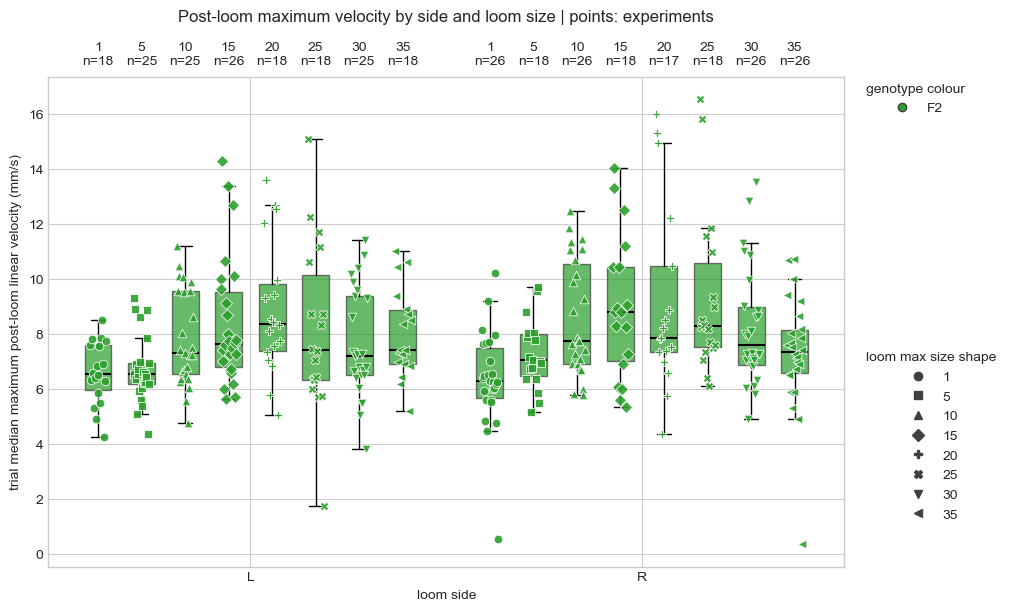

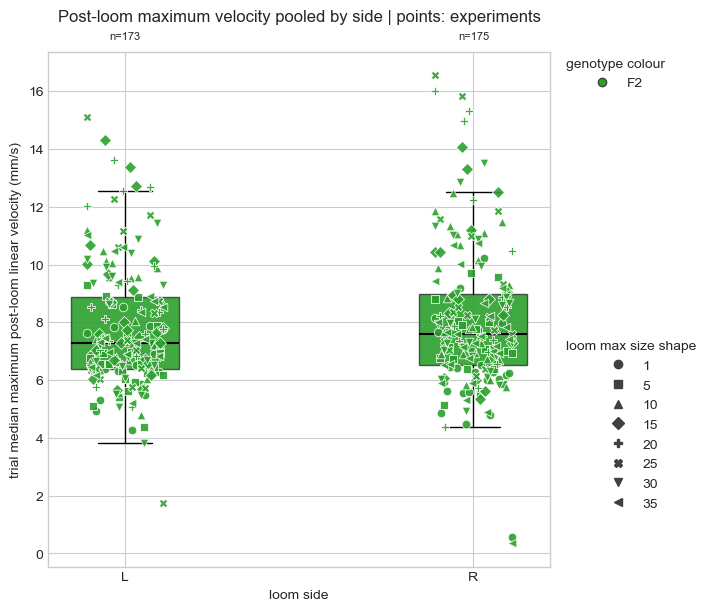

,loom_max_size,side,genotype,trial_median_max_linear_velocity_mm_s_mean,n_fish_mean,trial_median_max_linear_velocity_mm_s_sem,n_fish_sem,n_experiments
0,1,L,f2,6.577428,26.25,0.405418,2.547758,8
2,5,L,f2,6.721326,26.25,0.424323,2.547758,8
4,10,L,f2,7.813891,26.25,0.569181,2.547758,8
6,15,L,f2,8.370180,26.25,0.772046,2.547758,8
8,20,L,f2,8.919280,26.25,0.926464,2.547758,8
10,25,L,f2,8.264054,26.25,0.954713,2.547758,8
12,30,L,f2,7.632023,26.25,0.648472,2.547758,8
14,35,L,f2,7.954439,26.25,0.583570,2.547758,8
1,1,R,f2,6.478867,26.25,0.503813,2.547758,8
3,5,R,f2,7.357713,26.25,0.430534,2.547758,8


,experiment_index,experiment,trial,condition_trial,block,episode,side,loom_max_size,condition,fixed_loom_onset_frame,time_since_experiment_start_s,time_since_experiment_start_min,genotype,trial_median_max_linear_velocity_mm_s,n_fish,txt_path,plot_value,n_experiments
2,1,20260511_q2_Sel1A_s2,0,1,24,CLfull001L,L,1,1 L,216150,7205.0,120.083333,f2,7.619875,27,\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...,7.619875,1
122,2,20260512_q3_Sel3C_s1,0,1,24,CLfull001L,L,1,1 L,216150,7205.0,120.083333,f2,6.855551,14,\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...,6.855551,1
242,3,20260512_q4_Sel3C_s2,0,1,24,CLfull001L,L,1,1 L,216150,7205.0,120.083333,f2,4.924429,17,\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...,4.924429,1
362,4,20260518_q5_Sel3D_s1,0,1,24,CLfull001L,L,1,1 L,216150,7205.0,120.083333,f2,5.303301,31,\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...,5.303301,1
482,5,20260518_q6_Sel3D_s2,0,1,24,CLfull001L,L,1,1 L,216150,7205.0,120.083333,f2,6.388150,30,\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...,6.388150,1
602,6,20260519_q7_Sel1B_s1,0,1,24,CLfull001L,L,1,1 L,216150,7205.0,120.083333,f2,6.569729,30,\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...,6.569729,1
722,7,20260519_q8_Sel1B_s2,0,1,24,CLfull001L,L,1,1 L,216150,7205.0,120.083333,f2,7.833197,26,\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...,7.833197,1
841,8,20260626_q9_Sel1A_s2,0,1,24,CLfull001L,L,1,1 L,216150,7205.0,120.083333,f2,6.329494,35,\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...,6.329494,1
71,1,20260511_q2_Sel1A_s2,23,2,47,CLfull001L,L,1,1 L,278250,9275.0,154.583333,f2,8.533024,27,\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...,8.533024,1
191,2,20260512_q3_Sel3C_s1,23,2,47,CLfull001L,L,1,1 L,278250,9275.0,154.583333,f2,7.576874,14,\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...,7.576874,1


In [10]:
# Choose point aggregation and which loom sides to compare.
SIDE_POINT_MODE = 'experiments'  # 'experiments' or 'condition_trial_average'
TRIAL_MAX_VELOCITY_BOXPLOT_SIDES = ['L', 'R']
validate_point_mode(SIDE_POINT_MODE)

# Apply loom-size, side, and genotype filters to the maximum-velocity table.
side_source = trial_max_velocity.loc[
    trial_max_velocity['loom_max_size'].gt(MAX_LOOM_SIZE_EXCLUDE_THRESHOLD)
    & trial_max_velocity['side'].isin(TRIAL_MAX_VELOCITY_BOXPLOT_SIDES)
].copy()
side_source = select_plot_rows(side_source)
value_column = 'trial_median_max_linear_velocity_mm_s'
# Convert either raw experiment rows or across-experiment averages into a
# shared `plot_value` column used by both boxplots.
if SIDE_POINT_MODE == 'experiments':
    side_points = side_source.copy()
    side_points['plot_value'] = side_points[value_column]
    side_points['n_experiments'] = 1
else:
    side_points = loom.summarize_across_experiments(
        side_source, plot_group_columns(['loom_max_size', 'side', 'condition_trial']), [value_column, 'n_fish']
    ).rename(columns={f'{value_column}_mean': 'plot_value'})
# Remove non-finite values, find observed loom sizes, and map each size to a marker.
side_points = side_points.loc[np.isfinite(side_points['plot_value'])].copy()
sizes = sorted(side_points['loom_max_size'].unique())
size_marker_symbols = ['o', 's', '^', 'D', 'P', 'X', 'v', '<', '>']
SIZE_MARKERS = {
    size: size_marker_symbols[index % len(size_marker_symbols)]
    for index, size in enumerate(sizes)
}
plot_genotypes = ACTIVE_GENOTYPES if SPLIT_PLOTS_BY_GENOTYPE else [loom.POOLED_GENOTYPE]
# These plots do not use mean ± SEM or SD error bars. Each box spans the 25th
# to 75th percentiles (the interquartile range, IQR), the black line is the
# median, and whiskers reach the most extreme values within 1.5 × IQR.
# Matplotlib's separate outlier symbols are hidden because all values are
# overlaid explicitly as jittered scatter points.
box_kwargs = dict(widths=0.62, patch_artist=True, showfliers=False, manage_ticks=False, medianprops={'color': 'black', 'linewidth': 1.5})

fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)
group_centers = []
# First figure: allocate a position to every side × size × genotype combination.
group_spacing = len(sizes) * len(plot_genotypes) + 1
for side_index, side in enumerate(TRIAL_MAX_VELOCITY_BOXPLOT_SIDES):
    positions = []
    for size_index, size in enumerate(sizes):
        for genotype_index, genotype in enumerate(plot_genotypes):
            # Select points for one box. Skip empty combinations so no empty glyph is drawn.
            subset = side_points.loc[side_points['side'].eq(side) & side_points['loom_max_size'].eq(size) & side_points['genotype'].eq(genotype)].sort_values('condition_trial')
            if subset.empty:
                continue
            position = side_index * group_spacing + size_index * len(plot_genotypes) + genotype_index
            positions.append(position)
            values = subset['plot_value'].to_numpy(dtype=float)
            color = GENOTYPE_COLORS[genotype] if SPLIT_PLOTS_BY_GENOTYPE else '0.88'
            # Draw the distribution as a boxplot, overlay jittered individual points,
            # and annotate loom size plus the number of plotted values above each box.
            ax.boxplot([values], positions=[position], boxprops={'facecolor': color, 'edgecolor': '0.25', 'alpha': 0.72}, **box_kwargs)
            ax.scatter(position + deterministic_jitter(len(values), 0.18), values, color=color, marker=SIZE_MARKERS[size], s=38, alpha=0.9, edgecolors='white', linewidths=0.6, zorder=3)
            ax.text(position, 1.02, f'{int(size)}\nn={len(values)}', transform=ax.get_xaxis_transform(), ha='center', va='bottom', fontsize=10)
    # Put the x tick at the average position of all boxes belonging to one side.
    group_centers.append(np.mean(positions))
ax.set_xticks(group_centers)
ax.set_xticklabels(TRIAL_MAX_VELOCITY_BOXPLOT_SIDES)
ax.set_xlabel('loom side')
ax.set_ylabel('trial median maximum post-loom linear velocity (mm/s)')
ax.set_title(f'Post-loom maximum velocity by side and loom size | points: {SIDE_POINT_MODE}', pad=40)
# Create separate legends: colour explains genotype; shape explains loom size.
size_handles = [plt.Line2D([], [], marker=SIZE_MARKERS[size], linestyle='None', color='0.25', label=str(int(size))) for size in sizes]
if SPLIT_PLOTS_BY_GENOTYPE:
    genotype_handles = [plt.Line2D([], [], marker='o', linestyle='None', markerfacecolor=GENOTYPE_COLORS[g], markeredgecolor='0.25', label=genotype_display(g)) for g in plot_genotypes]
    genotype_legend = ax.legend(handles=genotype_handles, title='genotype colour', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
    ax.add_artist(genotype_legend)
ax.legend(handles=size_handles, title='loom max size shape', bbox_to_anchor=(1.02, 0.45 if SPLIT_PLOTS_BY_GENOTYPE else 1), loc='upper left', borderaxespad=0)
plt.show()

# Second figure: pool loom sizes within each side/genotype box while retaining
# size information in the overlaid point shapes.
fig, ax = plt.subplots(figsize=(7, 6), constrained_layout=True)
# Store plotting positions and compute a centered tick location for each side.
positions = {}
group_centers = []
for side_index, side in enumerate(TRIAL_MAX_VELOCITY_BOXPLOT_SIDES):
    side_positions = []
    for genotype_index, genotype in enumerate(plot_genotypes):
        position = side_index * (len(plot_genotypes) + 1) + genotype_index
        positions[(side, genotype)] = position
        side_positions.append(position)
        subset = side_points.loc[side_points['side'].eq(side) & side_points['genotype'].eq(genotype)].sort_values(['loom_max_size', 'condition_trial'])
        values = subset['plot_value'].to_numpy(dtype=float)
        color = GENOTYPE_COLORS[genotype] if SPLIT_PLOTS_BY_GENOTYPE else '0.88'
        ax.boxplot([values], positions=[position], boxprops={'facecolor': color, 'edgecolor': '0.25', 'alpha': 0.9}, **box_kwargs)
        # Overlay one jittered point group per loom size using its assigned marker.
        for size, size_subset in subset.groupby('loom_max_size', sort=True):
            size_values = size_subset['plot_value'].to_numpy(dtype=float)
            ax.scatter(position + deterministic_jitter(len(size_values), 0.22), size_values, color=color, marker=SIZE_MARKERS[size], s=38, alpha=0.9, edgecolors='white', linewidths=0.6, zorder=3)
        ax.text(position, 1.02, f'n={len(values)}', transform=ax.get_xaxis_transform(), ha='center', va='bottom', fontsize=8)
    group_centers.append(np.mean(side_positions))
ax.set_xticks(group_centers)
ax.set_xticklabels(TRIAL_MAX_VELOCITY_BOXPLOT_SIDES)
ax.set_xlabel('loom side')
ax.set_ylabel('trial median maximum post-loom linear velocity (mm/s)')
ax.set_title(f'Post-loom maximum velocity pooled by side | points: {SIDE_POINT_MODE}', pad=22)
if SPLIT_PLOTS_BY_GENOTYPE:
    genotype_legend = ax.legend(handles=genotype_handles, title='genotype colour', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
    ax.add_artist(genotype_legend)
ax.legend(handles=size_handles, title='loom max size shape', bbox_to_anchor=(1.02, 0.45 if SPLIT_PLOTS_BY_GENOTYPE else 1), loc='upper left', borderaxespad=0)
plt.show()
# Finally calculate and display the across-experiment statistics behind the plots.
max_velocity_stats = loom.summarize_across_experiments(
    side_source, plot_group_columns(['loom_max_size', 'side']), [value_column, 'n_fish']
)
display(max_velocity_stats.sort_values(['genotype', 'side', 'loom_max_size']))
display(side_points.sort_values(['genotype', 'side', 'loom_max_size', 'condition_trial']).head(30))

## 5. Hi/lo loom responses in Sel1 versus Sel3 line families

This section uses the existing experiment-level loom tables to compare hi and lo fish separately within Sel1 and Sel3 line families. Sel1_GC experiments are excluded here only. Sel1/TLSel1 and Sel3/TLSel3 labels are pooled into their respective families; an experiment carrying labels from both families is rejected because its cached experiment-level rows cannot be separated safely.

In [ ]:
# Import regular expressions, which match flexible patterns in line names.
import re

# Restrict the comparison to these line families and genotypes, in this order.
LINE_FAMILY_ORDER = ['Sel1', 'Sel3']
LINE_FAMILY_GENOTYPES = ['hi', 'lo']

# Convert the possibly multiple line labels for one experiment into one family.
def classify_loom_line_family(line_labels):
    """Classify one experiment without assigning Sel1_GC to the Sel1 family."""
    # Always work with a list: wrap a single label, but keep existing collections.
    # Normalize capitalization/whitespace so matching is robust.
    labels = line_labels if isinstance(line_labels, (list, tuple, set, np.ndarray, pd.Series)) else [line_labels]
    normalized_labels = [str(label).strip().lower() for label in labels]
    # Cached rows are experiment-level, so any experiment containing a GC line
    # must be excluded as a whole rather than partially assigned to Sel1 or Sel3.
    # Exclude any experiment containing a Sel1_GC label as a whole.
    if any(re.match(r'^(?:tl)?sel1_gc', label) for label in normalized_labels):
        return None
    # Match optional `tl` followed by Sel1 or Sel3. A set removes repeat labels.
    families = set()
    for normalized in normalized_labels:
        if not normalized or normalized in {'nan', 'none'}:
            continue
        if re.match(r'^(?:tl)?sel1', normalized):
            families.add('Sel1')
        elif re.match(r'^(?:tl)?sel3', normalized):
            families.add('Sel3')
    # Mixed-family experiments are ambiguous and therefore raise an explicit error.
    # `next(..., None)` returns the only family, or None if no family matched.
    if len(families) > 1:
        raise ValueError(f'Experiment mixes Sel1 and Sel3 line labels: {line_labels!r}')
    return next(iter(families), None)

# Classify every selected experiment and assemble a tidy lookup table.
line_family_records = []
for experiment_row in experiments[['experiment', 'lines']].itertuples(index=False):
    line_family_records.append({
        'experiment': str(experiment_row.experiment),
        'line_family': classify_loom_line_family(experiment_row.lines),
        'line_labels': ', '.join(map(str, experiment_row.lines)),
    })
line_family_catalog = pd.DataFrame(line_family_records)
# As a defensive check, verify each experiment maps to no more than one family.
conflicting_assignments = (
    line_family_catalog.dropna(subset=['line_family'])
    .groupby('experiment')['line_family'].nunique()
)
if conflicting_assignments.gt(1).any():
    raise ValueError('At least one experiment has conflicting Sel1/Sel3 family assignments.')
# Create a Series indexed by experiment name for fast mapping onto analysis rows.
line_family_map = (
    line_family_catalog.drop_duplicates('experiment').set_index('experiment')['line_family']
)

# Copy each needed analysis table, add its family label, and retain only the
# requested family/genotype combinations.
line_family_tables = {}
for table_name in ['center_traces', 'response_metrics', 'trial_max_velocity']:
    family_table = loom_tables[table_name].copy()
    family_table['line_family'] = family_table['experiment'].astype(str).map(line_family_map)
    family_table = family_table.loc[
        family_table['line_family'].isin(LINE_FAMILY_ORDER)
        & family_table['genotype'].isin(LINE_FAMILY_GENOTYPES)
    ].copy()
    line_family_tables[table_name] = family_table

# Count both independent experiments and total rows for every family/genotype.
line_family_counts = (
    line_family_tables['trial_max_velocity']
    .groupby(['line_family', 'genotype'], as_index=False)
    .agg(n_experiments=('experiment', 'nunique'), n_rows=('experiment', 'size'))
)
# Build all expected combinations with a MultiIndex and subtract observed ones.
missing_family_genotypes = pd.MultiIndex.from_product(
    [LINE_FAMILY_ORDER, LINE_FAMILY_GENOTYPES], names=['line_family', 'genotype']
).difference(pd.MultiIndex.from_frame(line_family_counts[['line_family', 'genotype']]))
if len(missing_family_genotypes):
    print('WARNING: No maximum-velocity data for:', list(missing_family_genotypes))
display(line_family_catalog.sort_values(['line_family', 'experiment'], na_position='last'))
display(line_family_counts)


### Legacy distance traces and merged response metrics

Each family is rendered separately with common axis limits. As above, traces and error bars treat experiments as equally weighted replicates.

In [ ]:
# CENTER-DISTANCE FIGURES: summarize each family separately over the same frame window.
line_family_center_stats = {}
center_family_source = line_family_tables['center_traces'].loc[
    line_family_tables['center_traces']['relative_frame'].between(*CENTER_TRACE_FRAME_RANGE)
].copy()
for line_family in LINE_FAMILY_ORDER:
    family_source = center_family_source.loc[center_family_source['line_family'].eq(line_family)]
    line_family_center_stats[line_family] = loom.summarize_across_experiments(
        family_source,
        ['loom_max_size', 'side', 'relative_frame', 'genotype'],
        ['center_dist_mm'],
    ) if not family_source.empty else pd.DataFrame()

# Add family labels and concatenate nonempty results for shared limits/checks.
nonempty_center_stats = [frame.assign(line_family=family) for family, frame in line_family_center_stats.items() if not frame.empty]
combined_center_stats = pd.concat(nonempty_center_stats, ignore_index=True) if nonempty_center_stats else pd.DataFrame()
if combined_center_stats.empty:
    raise ValueError('No Sel1/Sel3 hi/lo center-distance rows are available.')
family_center_sizes = sorted(combined_center_stats['loom_max_size'].unique())
# Calculate one y-range (mean ± SEM plus padding) shared by all family figures,
# making their vertical scales directly comparable.
center_low = (combined_center_stats['center_dist_mm_mean'] - combined_center_stats['center_dist_mm_sem'].fillna(0)).min()
center_high = (combined_center_stats['center_dist_mm_mean'] + combined_center_stats['center_dist_mm_sem'].fillna(0)).max()
center_pad = max((center_high - center_low) * 0.05, 0.05)

# Draw one 2-by-size panel grid per family, using side as rows and size as columns.
for line_family in LINE_FAMILY_ORDER:
    family_stats = line_family_center_stats[line_family]
    fig, axes = plt.subplots(2, len(family_center_sizes), figsize=(22, 7), sharex=True, sharey=True, constrained_layout=True)
    if len(family_center_sizes) == 1:
        axes = np.asarray(axes).reshape(2, 1)
    for row_index, side in enumerate(['R', 'L']):
        for column_index, size in enumerate(family_center_sizes):
            ax = axes[row_index, column_index]
            for genotype in LINE_FAMILY_GENOTYPES:
                # Select a genotype trace; if it exists, draw its mean and shaded SEM band.
                trace = family_stats.loc[
                    family_stats['side'].eq(side)
                    & family_stats['loom_max_size'].eq(size)
                    & family_stats['genotype'].eq(genotype)
                ].sort_values('relative_frame') if not family_stats.empty else pd.DataFrame()
                if trace.empty:
                    continue
                x = trace['relative_frame'].to_numpy(dtype=float)
                mean = trace['center_dist_mm_mean'].to_numpy(dtype=float)
                sem = trace['center_dist_mm_sem'].fillna(0).to_numpy(dtype=float)
                # The line is the mean across experiments. The shaded area is mean
                # ± one SEM across experiments, not a standard-deviation band.
                # If SEM is unavailable, `fillna(0)` collapses the band onto the mean.
                ax.plot(x, mean, color=GENOTYPE_COLORS[genotype], lw=2, label=genotype_display(genotype))
                ax.fill_between(x, mean - sem, mean + sem, color=GENOTYPE_COLORS[genotype], alpha=0.18, lw=0)
            ax.axvline(0, color='0.25', lw=0.8)
            ax.set_ylim(center_low - center_pad, center_high + center_pad)
            ax.set_title(f'{side}, {size / 2:.1f} mm')
            if column_index == 0:
                ax.set_ylabel('center distance (mm)')
            if row_index == 1:
                ax.set_xlabel('frames from fixed onset')
    axes[0, -1].legend(title='genotype', bbox_to_anchor=(1.02, 1), loc='upper left')
    fig.suptitle(f'{line_family}: legacy center-distance traces by genotype', y=1.04)
    plt.show()

# MERGED-RESPONSE FIGURES: use left/right-merged response rows and the point
# representation selected earlier in the notebook.
validate_point_mode(BASELINE_POINT_MODE)
merged_family_source = line_family_tables['response_metrics'].loc[
    line_family_tables['response_metrics']['aggregation'].eq('lr_merged')
].copy()
# Summarize every family by loom size and genotype.
line_family_merged_stats = {}
for line_family in LINE_FAMILY_ORDER:
    family_source = merged_family_source.loc[merged_family_source['line_family'].eq(line_family)]
    line_family_merged_stats[line_family] = loom.summarize_across_experiments(
        family_source, ['loom_max_size', 'genotype'],
        ['escape', 'response_dist', 'response_over_baseline', 'n_animals'],
    ) if not family_source.empty else pd.DataFrame()
nonempty_merged_stats = [frame.assign(line_family=family) for family, frame in line_family_merged_stats.items() if not frame.empty]
combined_merged_stats = pd.concat(nonempty_merged_stats, ignore_index=True) if nonempty_merged_stats else pd.DataFrame()
if combined_merged_stats.empty:
    raise ValueError('No Sel1/Sel3 hi/lo merged-response rows are available.')
family_response_sizes = sorted(merged_family_source['loom_max_size'].unique())
# Convert diameter to displayed size, offset genotypes, and calculate a shared
# response-distance y-range for fair comparisons between families.
family_response_x = np.asarray(family_response_sizes, dtype=float) / 2.0
family_genotype_offsets = dict(zip(LINE_FAMILY_GENOTYPES, np.linspace(-0.12, 0.12, len(LINE_FAMILY_GENOTYPES))))
response_low = (combined_merged_stats['response_dist_mean'] - combined_merged_stats['response_dist_sem'].fillna(0)).min()
response_high = (combined_merged_stats['response_dist_mean'] + combined_merged_stats['response_dist_sem'].fillna(0)).max()
response_pad = max((response_high - response_low) * 0.05, 0.05)

for line_family in LINE_FAMILY_ORDER:
    family_source = merged_family_source.loc[merged_family_source['line_family'].eq(line_family)]
    family_stats = line_family_merged_stats[line_family]
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), constrained_layout=True)
    # Draw escape fraction and response distance in neighboring panels.
    for ax, metric, ylabel in [(axes[0], 'escape', 'escape fraction'), (axes[1], 'response_dist', 'legacy response distance')]:
        for genotype in LINE_FAMILY_GENOTYPES:
            for size_index, size in enumerate(family_response_sizes):
                position = family_response_x[size_index] + family_genotype_offsets[genotype]
                # Retrieve raw experiment values and their matching one-row summary.
                raw = family_source.loc[family_source['loom_max_size'].eq(size) & family_source['genotype'].eq(genotype)]
                stats = family_stats.loc[family_stats['loom_max_size'].eq(size) & family_stats['genotype'].eq(genotype)] if not family_stats.empty else pd.DataFrame()
                if stats.empty:
                    continue
                stats = stats.iloc[0]
                # Show raw jittered points or one average point, then always overlay mean ± SEM.
                if BASELINE_POINT_MODE == 'experiments':
                    values = raw[metric].dropna().to_numpy(dtype=float)
                    ax.scatter(position + deterministic_jitter(len(values), 0.05), values, color=GENOTYPE_COLORS[genotype], alpha=0.55, s=24)
                else:
                    ax.scatter(position, stats[f'{metric}_mean'], color=GENOTYPE_COLORS[genotype], s=42, zorder=3)
                # The marker is the across-experiment mean and the vertical error
                # bar is mean ± one SEM across experiments (not standard deviation).
                ax.errorbar(position, stats[f'{metric}_mean'], yerr=stats[f'{metric}_sem'], color=GENOTYPE_COLORS[genotype], marker='o', capsize=3, ms=5, zorder=4)
        ax.set_xlabel('loom size (mm)')
        ax.set_ylabel(ylabel)
        ax.set_xticks(family_response_x)
        ax.set_title('L/R merged')
    axes[0].set_ylim(-0.05, 1.05)
    axes[1].set_ylim(response_low - response_pad, response_high + response_pad)
    axes[-1].legend(handles=[plt.Line2D([], [], marker='o', color=GENOTYPE_COLORS[g], linestyle='None', label=genotype_display(g)) for g in LINE_FAMILY_GENOTYPES], title='genotype', bbox_to_anchor=(1.02, 1), loc='upper left')
    fig.suptitle(f'{line_family}: legacy response metrics merged across L/R | points: {BASELINE_POINT_MODE}', y=1.04)
    plt.show()

# Concatenate and display the exact summary tables used to make the figures.
display(pd.concat(nonempty_center_stats, ignore_index=True).sort_values(['line_family', 'genotype', 'loom_max_size', 'side', 'relative_frame']))
display(pd.concat(nonempty_merged_stats, ignore_index=True).sort_values(['line_family', 'genotype', 'loom_max_size']))


### Maximum post-loom velocity plots

The time-based Gaussian summaries and both side-based layouts use the same settings as the corresponding plots above. Corresponding Sel1 and Sel3 figures use common axis limits.

In [ ]:
# Reuse validated point modes and create the eligible Sel1/Sel3 maximum-velocity source.
validate_point_mode(TIME_POINT_MODE)
validate_point_mode(SIDE_POINT_MODE)
family_max_source = line_family_tables['trial_max_velocity'].loc[
    line_family_tables['trial_max_velocity']['loom_max_size'].gt(MAX_LOOM_SIZE_EXCLUDE_THRESHOLD)
].copy()
family_value_column = 'trial_median_max_linear_velocity_mm_s'
if family_max_source.empty:
    raise ValueError('No Sel1/Sel3 hi/lo maximum-velocity rows pass the loom-size threshold.')

# Standardize raw or averaged family data to plot_x/plot_y and SEM columns.
if TIME_POINT_MODE == 'experiments':
    family_time_points = family_max_source.copy()
    family_time_points['plot_x'] = family_time_points['time_since_experiment_start_min']
    family_time_points['plot_y'] = family_time_points[family_value_column]
    family_time_points['plot_x_sem'] = np.nan
    family_time_points['plot_y_sem'] = np.nan
    family_time_points['n_experiments'] = 1
else:
    family_time_points = loom.summarize_across_experiments(
        family_max_source,
        ['line_family', 'genotype', 'loom_max_size', 'side', 'condition_trial'],
        ['time_since_experiment_start_min', family_value_column],
    ).rename(columns={
        'time_since_experiment_start_min_mean': 'plot_x',
        'time_since_experiment_start_min_sem': 'plot_x_sem',
        f'{family_value_column}_mean': 'plot_y',
        f'{family_value_column}_sem': 'plot_y_sem',
    })
# Create condition labels and assign marker shapes as in the all-lines plot.
family_time_points['condition'] = family_time_points['loom_max_size'].astype(int).astype(str) + ' ' + family_time_points['side'].astype(str)
family_conditions = family_time_points[['loom_max_size', 'side', 'condition']].drop_duplicates().sort_values(['loom_max_size', 'side'])
family_condition_markers = {
    condition: condition_marker_symbols[index % len(condition_marker_symbols)]
    for index, condition in enumerate(family_conditions['condition'])
}
# Keep finite values, define a common time origin, and prepare fit-result containers.
finite_family_time = family_time_points[['plot_x', 'plot_y']].replace([np.inf, -np.inf], np.nan).dropna()
family_fit_time_origin = finite_family_time['plot_x'].min()
family_fit_rows = []
family_fit_parameters = {}
# Fit one Gaussian peak independently for every family × genotype combination.
for line_family in LINE_FAMILY_ORDER:
    for genotype in LINE_FAMILY_GENOTYPES:
        fit_data = (
            family_time_points.loc[
                family_time_points['line_family'].eq(line_family) & family_time_points['genotype'].eq(genotype),
                ['plot_x', 'plot_y'],
            ].replace([np.inf, -np.inf], np.nan).dropna().sort_values('plot_x')
        )
        # Initialize a complete result record so fit failures remain visible in output.
        fit_result = {
            'line_family': line_family, 'genotype': genotype,
            'fitted_floor_mm_s': np.nan, 'amplitude_mm_s': np.nan,
            'peak_velocity_mm_s': np.nan, 'peak_time_min': np.nan,
            'width_min': np.nan, 'max_decrease_rate_mm_s_per_min': np.nan,
            'max_decrease_time_min': np.nan, 'half_decay_time_min': np.nan,
            'r_squared': np.nan, 'n_points': len(fit_data), 'fit_status': 'not fitted',
        }
        parameters = None
        # Check minimum data requirements before estimating bounded starting values.
        if len(fit_data) < 5:
            fit_result['fit_status'] = 'insufficient finite points (need at least 5)'
        elif fit_data['plot_x'].nunique() < 2:
            fit_result['fit_status'] = 'no time variation'
        else:
            elapsed_time = fit_data['plot_x'].to_numpy(dtype=float) - family_fit_time_origin
            velocity = fit_data['plot_y'].to_numpy(dtype=float)
            time_span = float(np.ptp(elapsed_time))
            velocity_scale = max(float(np.nanmax(velocity)), np.finfo(float).eps)
            initial_floor = np.clip(float(np.nanmin(velocity)) * 0.8, 0, velocity_scale * 0.95)
            initial_amplitude = max(float(np.nanmax(velocity)) - initial_floor, np.finfo(float).eps)
            initial_peak_time = float(elapsed_time[np.nanargmax(velocity)])
            minimum_width = min(0.5, time_span)
            maximum_width = max(time_span * 2, minimum_width + np.finfo(float).eps)
            # Attempt nonlinear fitting and convert fitted parameters into peak/decay summaries.
            try:
                parameters, _ = curve_fit(
                    gaussian_peak, elapsed_time, velocity,
                    p0=(initial_floor, initial_amplitude, initial_peak_time, np.clip(time_span / 6, minimum_width, maximum_width)),
                    bounds=((0, 0, 0, minimum_width), (velocity_scale, np.inf, time_span, maximum_width)),
                    maxfev=50000,
                )
                fitted_floor, amplitude, peak_elapsed_time, width = parameters
                fitted_velocity = gaussian_peak(elapsed_time, *parameters)
                residual_sum_squares = np.sum((velocity - fitted_velocity) ** 2)
                total_sum_squares = np.sum((velocity - velocity.mean()) ** 2)
                peak_time = family_fit_time_origin + peak_elapsed_time
                fit_result.update({
                    'fitted_floor_mm_s': fitted_floor,
                    'amplitude_mm_s': amplitude,
                    'peak_velocity_mm_s': fitted_floor + amplitude,
                    'peak_time_min': peak_time,
                    'width_min': width,
                    'max_decrease_rate_mm_s_per_min': amplitude * np.exp(-0.5) / width,
                    'max_decrease_time_min': peak_time + width,
                    'half_decay_time_min': width * np.sqrt(2 * np.log(2)),
                    'r_squared': 1 - residual_sum_squares / total_sum_squares if total_sum_squares > 0 else np.nan,
                    'fit_status': 'ok',
                })
            except (RuntimeError, ValueError, FloatingPointError) as error:
                fit_result['fit_status'] = f'fit failed: {error}'
# Save parameters for plotting and the diagnostic dictionary for tabulation.
        family_fit_parameters[(line_family, genotype)] = parameters
        family_fit_rows.append(fit_result)
line_family_fit_summary = pd.DataFrame(family_fit_rows)

# Calculate common padded x/y limits so all family time plots share a scale.
time_x_pad = max((finite_family_time['plot_x'].max() - finite_family_time['plot_x'].min()) * 0.03, 1)
fit_peaks = line_family_fit_summary['peak_velocity_mm_s'].dropna()
time_y_high = max(finite_family_time['plot_y'].max(), fit_peaks.max() if not fit_peaks.empty else -np.inf)
time_y_low = min(0, finite_family_time['plot_y'].min())
time_y_pad = max((time_y_high - time_y_low) * 0.05, 0.05)
# TIME FIGURES: draw one family at a time, with condition shapes and genotype colours.
for line_family in LINE_FAMILY_ORDER:
    fig, ax = plt.subplots(figsize=(9, 6), constrained_layout=True)
    family_points = family_time_points.loc[family_time_points['line_family'].eq(line_family)]
    for condition in family_conditions['condition']:
        for genotype in LINE_FAMILY_GENOTYPES:
            subset = family_points.loc[family_points['condition'].eq(condition) & family_points['genotype'].eq(genotype)]
            if subset.empty:
                continue
            ax.scatter(subset['plot_x'], subset['plot_y'], color=GENOTYPE_COLORS[genotype], marker=family_condition_markers[condition], s=48, alpha=0.85, edgecolor='white', linewidth=0.7)
            # Only averaged points receive error bars: horizontal bars are ± one
            # SEM of time and vertical bars are ± one SEM of velocity, both across
            # experiments. Raw experiment points have no uncertainty bars.
            if TIME_POINT_MODE == 'condition_trial_average':
                ax.errorbar(subset['plot_x'], subset['plot_y'], xerr=subset['plot_x_sem'], yerr=subset['plot_y_sem'], fmt='none', ecolor=GENOTYPE_COLORS[genotype], alpha=0.65, capsize=2)
    # Overlay available fitted curves and build fit-aware genotype legend labels.
    genotype_handles = []
    for genotype in LINE_FAMILY_GENOTYPES:
        fit_row = line_family_fit_summary.loc[line_family_fit_summary['line_family'].eq(line_family) & line_family_fit_summary['genotype'].eq(genotype)].iloc[0]
        parameters = family_fit_parameters[(line_family, genotype)]
        if parameters is not None:
            fit_data = family_points.loc[family_points['genotype'].eq(genotype), 'plot_x'].dropna()
            fit_x = np.linspace(fit_data.min(), fit_data.max(), 250)
            # Draw only the best-fitting Gaussian curve; there is no confidence or
            # prediction interval around this fitted line.
            ax.plot(fit_x, gaussian_peak(fit_x - family_fit_time_origin, *parameters), color=GENOTYPE_COLORS[genotype], lw=2.2)
        label = genotype_display(genotype)
        label += f" ({fit_row['max_decrease_rate_mm_s_per_min']:.3g})" if fit_row['fit_status'] == 'ok' else ' (fit unavailable)'
        genotype_handles.append(plt.Line2D([], [], marker='o', color=GENOTYPE_COLORS[genotype], linestyle='-' if parameters is not None else 'None', lw=2.2, label=label))
        if fit_row['fit_status'] != 'ok':
            print(f"WARNING: {line_family} Gaussian fit for {genotype_display(genotype)} skipped ({fit_row['fit_status']}).")
    ax.set_xlim(finite_family_time['plot_x'].min() - time_x_pad, finite_family_time['plot_x'].max() + time_x_pad)
    ax.set_ylim(time_y_low - time_y_pad, time_y_high + time_y_pad)
    ax.set_xlabel('time since experiment start (min)')
    ax.set_ylabel('trial median max linear velocity (mm/s)')
    ax.set_title(f'{line_family}: trial max post-loom velocity vs time | points: {TIME_POINT_MODE}')
    genotype_legend = ax.legend(handles=genotype_handles, title='genotype / max fall\n(mm/s/min)', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
    ax.add_artist(genotype_legend)
    ax.legend(handles=[plt.Line2D([], [], marker=family_condition_markers[c], color='0.25', linestyle='None', label=c) for c in family_conditions['condition']], title='condition shape', bbox_to_anchor=(1.02, 0.70), loc='upper left', borderaxespad=0, ncol=2)
    plt.show()

# SIDE BOXPLOTS: select requested sides and standardize raw/averaged point values.
family_side_source = family_max_source.loc[family_max_source['side'].isin(TRIAL_MAX_VELOCITY_BOXPLOT_SIDES)].copy()
if SIDE_POINT_MODE == 'experiments':
    family_side_points = family_side_source.copy()
    family_side_points['plot_value'] = family_side_points[family_value_column]
    family_side_points['n_experiments'] = 1
else:
    family_side_points = loom.summarize_across_experiments(
        family_side_source,
        ['line_family', 'genotype', 'loom_max_size', 'side', 'condition_trial'],
        [family_value_column, 'n_fish'],
    ).rename(columns={f'{family_value_column}_mean': 'plot_value'})
family_side_points = family_side_points.loc[np.isfinite(family_side_points['plot_value'])].copy()
# Assign size markers and calculate shared y limits and boxplot styling.
family_side_sizes = sorted(family_side_points['loom_max_size'].unique())
family_size_markers = {size: size_marker_symbols[index % len(size_marker_symbols)] for index, size in enumerate(family_side_sizes)}
side_y_low = min(0, family_side_points['plot_value'].min())
side_y_high = family_side_points['plot_value'].max()
side_y_pad = max((side_y_high - side_y_low) * 0.05, 0.05)
# These are distribution summaries, not SEM or SD error bars. Boxes cover the
# 25th–75th percentiles, black lines mark medians, and whiskers extend to the
# most extreme values within 1.5 × IQR. All observations are overlaid as points,
# so Matplotlib's separate outlier symbols are intentionally hidden.
family_box_kwargs = dict(widths=0.62, patch_artist=True, showfliers=False, manage_ticks=False, medianprops={'color': 'black', 'linewidth': 1.5})

# Summarize each family, then create detailed (side × size × genotype) boxes.
line_family_max_velocity_stats = {}
for line_family in LINE_FAMILY_ORDER:
    family_stats_source = family_side_source.loc[family_side_source['line_family'].eq(line_family)]
    line_family_max_velocity_stats[line_family] = loom.summarize_across_experiments(
        family_stats_source, ['genotype', 'loom_max_size', 'side'], [family_value_column, 'n_fish']
    ) if not family_stats_source.empty else pd.DataFrame()
    plot_points = family_side_points.loc[family_side_points['line_family'].eq(line_family)]

    fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)
    group_centers = []
    # Reserve non-overlapping x positions for all combinations within each side.
    group_spacing = len(family_side_sizes) * len(LINE_FAMILY_GENOTYPES) + 1
    for side_index, side in enumerate(TRIAL_MAX_VELOCITY_BOXPLOT_SIDES):
        positions = []
        for size_index, size in enumerate(family_side_sizes):
            for genotype_index, genotype in enumerate(LINE_FAMILY_GENOTYPES):
                subset = plot_points.loc[plot_points['side'].eq(side) & plot_points['loom_max_size'].eq(size) & plot_points['genotype'].eq(genotype)].sort_values('condition_trial')
                if subset.empty:
                    continue
                position = side_index * group_spacing + size_index * len(LINE_FAMILY_GENOTYPES) + genotype_index
                positions.append(position)
                values = subset['plot_value'].to_numpy(dtype=float)
                ax.boxplot([values], positions=[position], boxprops={'facecolor': GENOTYPE_COLORS[genotype], 'edgecolor': '0.25', 'alpha': 0.72}, **family_box_kwargs)
                ax.scatter(position + deterministic_jitter(len(values), 0.18), values, color=GENOTYPE_COLORS[genotype], marker=family_size_markers[size], s=38, alpha=0.9, edgecolors='white', linewidths=0.6, zorder=3)
                ax.text(position, 1.02, f'{int(size)}\nn={len(values)}', transform=ax.get_xaxis_transform(), ha='center', va='bottom', fontsize=10)
        # Only add an x-axis group center when that side contains plotted boxes.
        if positions:
            group_centers.append((side, np.mean(positions)))
    ax.set_xticks([position for _, position in group_centers])
    ax.set_xticklabels([side for side, _ in group_centers])
    ax.set_ylim(side_y_low - side_y_pad, side_y_high + side_y_pad)
    ax.set_xlabel('loom side')
    ax.set_ylabel('trial median maximum post-loom linear velocity (mm/s)')
    ax.set_title(f'{line_family}: post-loom maximum velocity by side and loom size | points: {SIDE_POINT_MODE}', pad=40)
    genotype_handles = [plt.Line2D([], [], marker='o', linestyle='None', markerfacecolor=GENOTYPE_COLORS[g], markeredgecolor='0.25', label=genotype_display(g)) for g in LINE_FAMILY_GENOTYPES]
    size_handles = [plt.Line2D([], [], marker=family_size_markers[size], linestyle='None', color='0.25', label=str(int(size))) for size in family_side_sizes]
    genotype_legend = ax.legend(handles=genotype_handles, title='genotype colour', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
    ax.add_artist(genotype_legend)
    ax.legend(handles=size_handles, title='loom max size shape', bbox_to_anchor=(1.02, 0.45), loc='upper left', borderaxespad=0)
    plt.show()

    # Create a second figure pooling sizes into each side/genotype box; marker
    # shapes still reveal each observation's loom size.
    fig, ax = plt.subplots(figsize=(7, 6), constrained_layout=True)
    pooled_group_centers = []
    for side_index, side in enumerate(TRIAL_MAX_VELOCITY_BOXPLOT_SIDES):
        side_positions = []
        for genotype_index, genotype in enumerate(LINE_FAMILY_GENOTYPES):
            subset = plot_points.loc[plot_points['side'].eq(side) & plot_points['genotype'].eq(genotype)].sort_values(['loom_max_size', 'condition_trial'])
            if subset.empty:
                continue
            position = side_index * (len(LINE_FAMILY_GENOTYPES) + 1) + genotype_index
            side_positions.append(position)
            values = subset['plot_value'].to_numpy(dtype=float)
            ax.boxplot([values], positions=[position], boxprops={'facecolor': GENOTYPE_COLORS[genotype], 'edgecolor': '0.25', 'alpha': 0.9}, **family_box_kwargs)
            for size, size_subset in subset.groupby('loom_max_size', sort=True):
                size_values = size_subset['plot_value'].to_numpy(dtype=float)
                ax.scatter(position + deterministic_jitter(len(size_values), 0.22), size_values, color=GENOTYPE_COLORS[genotype], marker=family_size_markers[size], s=38, alpha=0.9, edgecolors='white', linewidths=0.6, zorder=3)
            ax.text(position, 1.02, f'n={len(values)}', transform=ax.get_xaxis_transform(), ha='center', va='bottom', fontsize=8)
        if side_positions:
            pooled_group_centers.append((side, np.mean(side_positions)))
    ax.set_xticks([position for _, position in pooled_group_centers])
    ax.set_xticklabels([side for side, _ in pooled_group_centers])
    ax.set_ylim(side_y_low - side_y_pad, side_y_high + side_y_pad)
    ax.set_xlabel('loom side')
    ax.set_ylabel('trial median maximum post-loom linear velocity (mm/s)')
    ax.set_title(f'{line_family}: post-loom maximum velocity pooled by side | points: {SIDE_POINT_MODE}', pad=22)
    genotype_legend = ax.legend(handles=genotype_handles, title='genotype colour', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
    ax.add_artist(genotype_legend)
    ax.legend(handles=size_handles, title='loom max size shape', bbox_to_anchor=(1.02, 0.45), loc='upper left', borderaxespad=0)
    plt.show()

# Display the fit diagnostics and all nonempty maximum-velocity summaries.
display(line_family_fit_summary.sort_values(['line_family', 'genotype']))
nonempty_max_stats = [frame.assign(line_family=family) for family, frame in line_family_max_velocity_stats.items() if not frame.empty]
display(pd.concat(nonempty_max_stats, ignore_index=True).sort_values(['line_family', 'genotype', 'side', 'loom_max_size']))
